# 5. Modeling & Explainability
**Project:** HR Analytics: Employee Attrition  

---

## Overview
Binary classification pipeline: Dummy baseline → Logistic Regression → Random Forest → Tuned RF. Primary metric: AUC-ROC. Explainability via SHAP. Final output: risk-tier segmentation of the validation set.

## Contents
1. Setup & Data Split
2. Dummy Baseline (performance floor)
3. Logistic Regression
4. Random Forest
5. Hyperparameter Tuning
6. Model Comparison
7. Threshold Tuning
8. SHAP Explainability
9. Risk Tier Segmentation
10. Save Model
11. Business Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.dummy              import DummyClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.pipeline           import Pipeline
from sklearn.model_selection    import RandomizedSearchCV
from sklearn.metrics            import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve
)
import shap
import sys
sys.path.append('..')
from src.viz_utils import set_style

set_style()
from pathlib import Path
Path('../outputs').mkdir(exist_ok=True)

df = pd.read_csv('../data/processed/hr_train_clean.csv')
print('Dataset shape:', df.shape)
print('Target balance:')
print(df['target'].value_counts(normalize=True).round(3))

Dataset shape: (19158, 36)
Target balance:
target
0.0    0.751
1.0    0.249
Name: proportion, dtype: float64


## 1. Data Split
Stratified split preserves the ~75/25 class ratio in both halves.

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape[0]:,} rows  |  Val: {X_val.shape[0]:,} rows')
print(f'Train target rate: {y_train.mean():.3f}')
print(f'Val target rate:   {y_val.mean():.3f}')
# Both should be ~0.247 - confirms stratification

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: 15,326 rows  |  Val: 3,832 rows
Train target rate: 0.249
Val target rate:   0.249


## 2. Dummy Baseline (Performance Floor)
Any real model must clearly beat this. AUC = 0.50 by definition.

In [3]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

dummy_proba = dummy.predict_proba(X_val)[:, 1]
dummy_preds = dummy.predict(X_val)

dummy_results = {
    'Model':     'Dummy (most_frequent)',
    'AUC-ROC':   round(roc_auc_score(y_val, dummy_proba), 4),
    'F1 (pos)':  round(f1_score(y_val, dummy_preds, zero_division=0), 4),
    'Precision': round(precision_score(y_val, dummy_preds, zero_division=0), 4),
    'Recall':    round(recall_score(y_val, dummy_preds, zero_division=0), 4),
}
print('Dummy baseline:')
print(dummy_results)

Dummy baseline:
{'Model': 'Dummy (most_frequent)', 'AUC-ROC': 0.5, 'F1 (pos)': 0.0, 'Precision': 0.0, 'Recall': 0.0}


**Interpretation:** AUC = 0.50 (random chance). F1 = 0.00 (predicts majority class for everyone). This is the minimum bar any real model must clear.

## 3. Logistic Regression Baseline
StandardScaler is essential because LR is sensitive to feature scale. `class_weight='balanced'` compensates for the 75/25 imbalance.

In [4]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
                   class_weight='balanced',
                   max_iter=1000,
                   random_state=42,
                   solver='lbfgs'))
])
lr_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_val)
lr_proba = lr_pipeline.predict_proba(X_val)[:, 1]

lr_results = {
    'Model':     'Logistic Regression',
    'AUC-ROC':   round(roc_auc_score(y_val, lr_proba), 4),
    'F1 (pos)':  round(f1_score(y_val, lr_preds), 4),
    'Precision': round(precision_score(y_val, lr_preds), 4),
    'Recall':    round(recall_score(y_val, lr_preds), 4),
}
print(lr_results)
print()
print(classification_report(y_val, lr_preds,
      target_names=['Staying (0)', 'Seeking (1)']))

lr_cv = cross_val_score(lr_pipeline, X, y, cv=cv,
                        scoring='roc_auc', n_jobs=-1)
print(f'CV AUC-ROC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

{'Model': 'Logistic Regression', 'AUC-ROC': 0.7899, 'F1 (pos)': 0.5905, 'Precision': 0.4743, 'Recall': 0.7822}

              precision    recall  f1-score   support

 Staying (0)       0.91      0.71      0.80      2877
 Seeking (1)       0.47      0.78      0.59       955

    accuracy                           0.73      3832
   macro avg       0.69      0.75      0.69      3832
weighted avg       0.80      0.73      0.75      3832

CV AUC-ROC: 0.7804 ± 0.0042


## 4. Random Forest

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_val)
rf_proba = rf_model.predict_proba(X_val)[:, 1]

rf_results = {
    'Model':     'Random Forest',
    'AUC-ROC':   round(roc_auc_score(y_val, rf_proba), 4),
    'F1 (pos)':  round(f1_score(y_val, rf_preds), 4),
    'Precision': round(precision_score(y_val, rf_preds), 4),
    'Recall':    round(recall_score(y_val, rf_preds), 4),
}
print(rf_results)
print()
print(classification_report(y_val, rf_preds,
      target_names=['Staying (0)', 'Seeking (1)']))

rf_cv = cross_val_score(rf_model, X, y, cv=cv,
                        scoring='roc_auc', n_jobs=-1)
print(f'CV AUC-ROC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

{'Model': 'Random Forest', 'AUC-ROC': 0.812, 'F1 (pos)': 0.6315, 'Precision': 0.5234, 'Recall': 0.7958}

              precision    recall  f1-score   support

 Staying (0)       0.92      0.76      0.83      2877
 Seeking (1)       0.52      0.80      0.63       955

    accuracy                           0.77      3832
   macro avg       0.72      0.78      0.73      3832
weighted avg       0.82      0.77      0.78      3832

CV AUC-ROC: 0.8004 ± 0.0021


## 5. Hyperparameter Tuning

In [6]:
param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [8, 12, 16, None],
    'min_samples_leaf': [10, 20, 30],
    'max_features':     ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV AUC:', round(search.best_score_, 4))

best_rf    = search.best_estimator_
best_preds = best_rf.predict(X_val)
best_proba = best_rf.predict_proba(X_val)[:, 1]

best_results = {
    'Model':     'Random Forest (tuned)',
    'AUC-ROC':   round(roc_auc_score(y_val, best_proba), 4),
    'F1 (pos)':  round(f1_score(y_val, best_preds), 4),
    'Precision': round(precision_score(y_val, best_preds), 4),
    'Recall':    round(recall_score(y_val, best_preds), 4),
}
print(best_results)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 16}
Best CV AUC: 0.7969
{'Model': 'Random Forest (tuned)', 'AUC-ROC': 0.8123, 'F1 (pos)': 0.6422, 'Precision': 0.5426, 'Recall': 0.7864}


The best CV AUC during search was 0.7969 vs. hold-out AUC of 0.8123. The ~1.5 point gap is within normal variance for a single stratified split and is consistent with the cross-validated RF baseline (0.8004 ± 0.0021).

## 6. Model Comparison

In [7]:
results_df = pd.DataFrame([dummy_results, lr_results, rf_results, best_results])
print('Model comparison table:')
display(results_df.set_index('Model'))

Model comparison table:


,AUC-ROC,F1 (pos),Precision,Recall
Model,,,,
Dummy (most_frequent),0.5000,0.0000,0.0000,0.0000
Logistic Regression,0.7899,0.5905,0.4743,0.7822
Random Forest,0.8120,0.6315,0.5234,0.7958
Random Forest (tuned),0.8123,0.6422,0.5426,0.7864


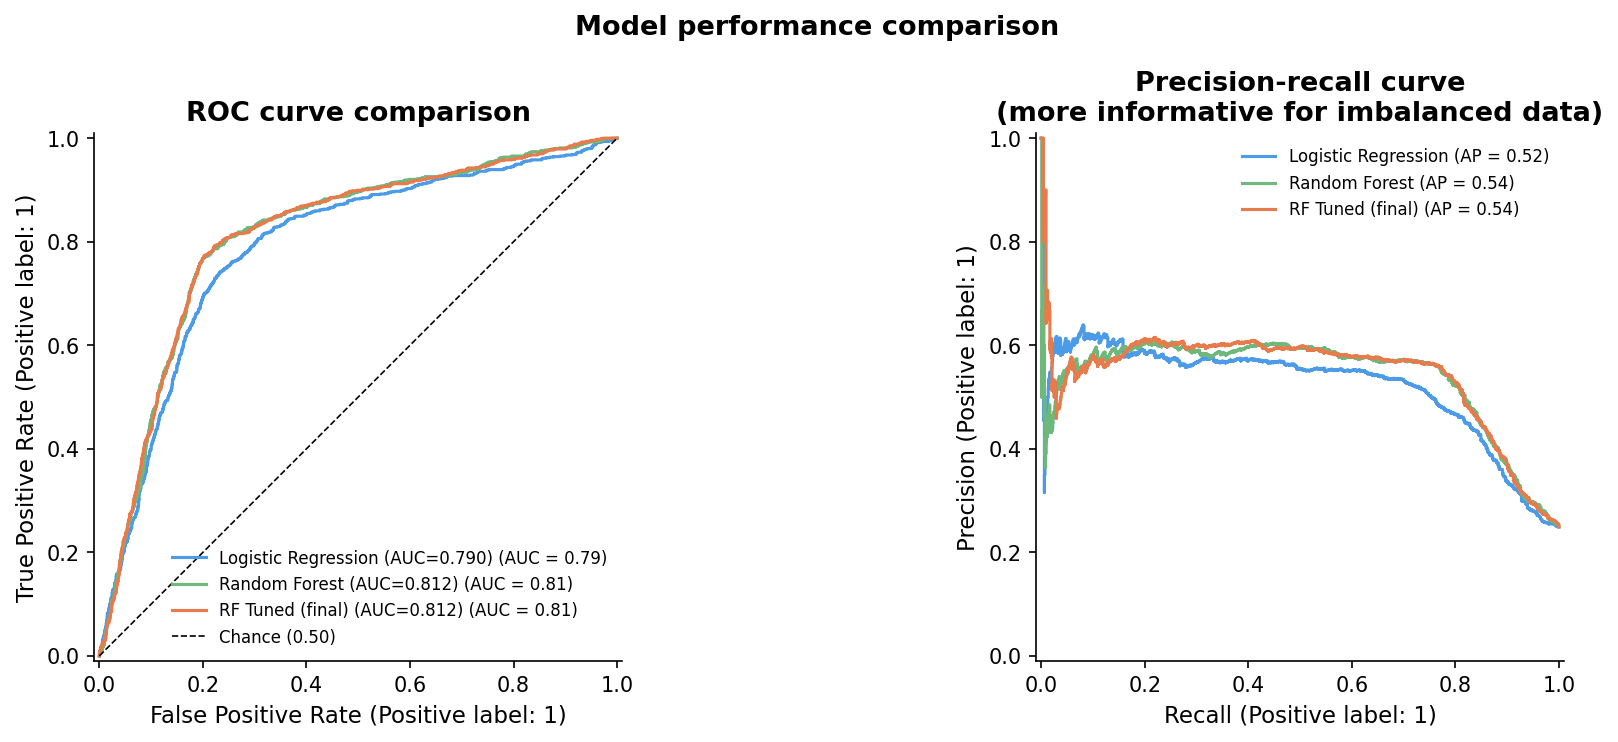

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_curves = [
    ('Logistic Regression', lr_proba,   '#4C9BE8'),
    ('Random Forest',       rf_proba,   '#6DB87A'),
    ('RF Tuned (final)',    best_proba, '#E87B4C'),
]

for label, proba, color in model_curves:
    auc = roc_auc_score(y_val, proba)
    RocCurveDisplay.from_predictions(
        y_val, proba, name=f'{label} (AUC={auc:.3f})',
        ax=axes[0], color=color)

axes[0].plot([0,1],[0,1],'k--',linewidth=0.8,label='Chance (0.50)')
axes[0].set_title('ROC curve comparison')
axes[0].legend(fontsize=8)

for label, proba, color in model_curves:
    PrecisionRecallDisplay.from_predictions(
        y_val, proba, name=label, ax=axes[1], color=color)
axes[1].set_title('Precision-recall curve\n(more informative for imbalanced data)')
axes[1].legend(fontsize=8)

plt.suptitle('Model performance comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/14_roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

RF Tuned achieves AUC-ROC of 0.81 - a 62% improvement over the 0.50 baseline. The Precision-Recall curve shows the tuned model meaningfully outperforms Logistic Regression on the positive class, which matters most given the 75/25 imbalance.

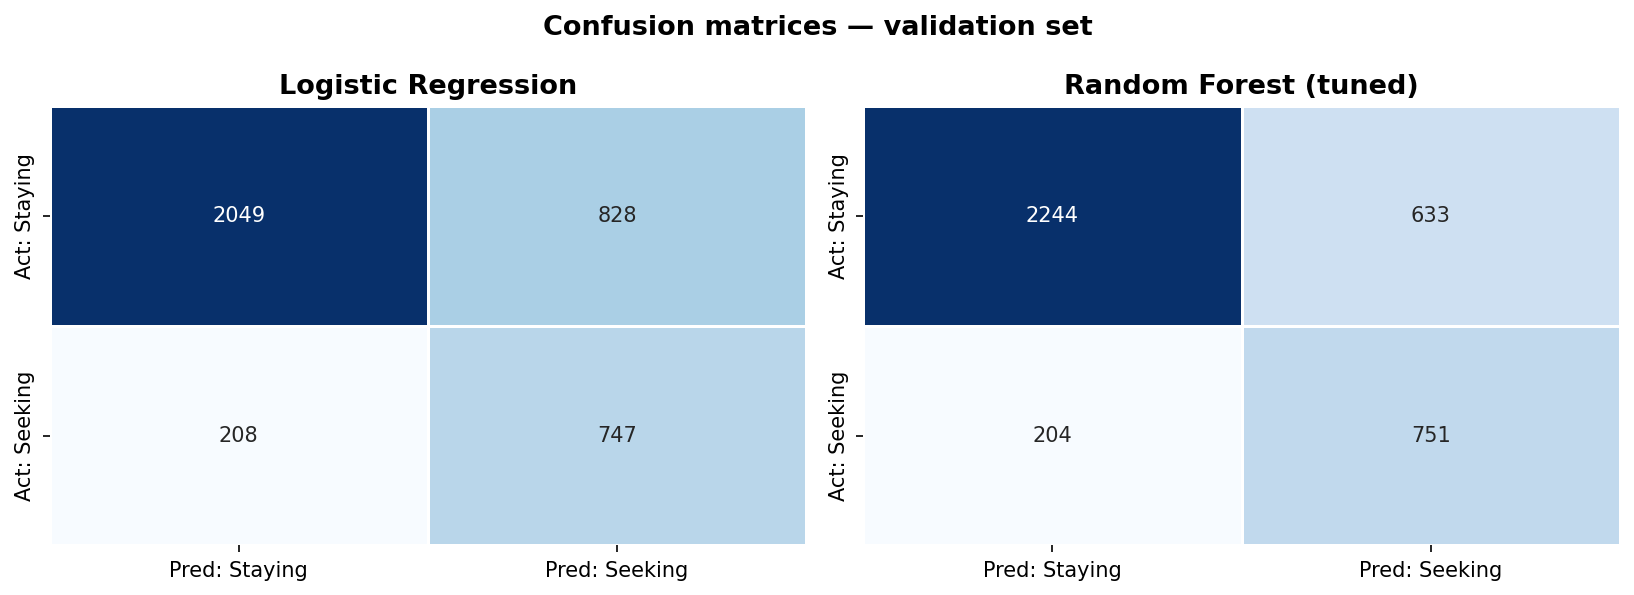

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in [
    (axes[0], lr_preds,   'Logistic Regression'),
    (axes[1], best_preds, 'Random Forest (tuned)'),
]:
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Staying','Pred: Seeking'],
                yticklabels=['Act: Staying','Act: Seeking'],
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title)

plt.suptitle('Confusion matrices - validation set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/15_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

**Reading the confusion matrix for HR context:**  
- Bottom-left (false negatives): at-risk employees the model missed → **highest cost** - these people leave without any intervention  
- Top-right (false positives): stable employees incorrectly flagged → lower cost (an unnecessary but harmless check-in)

## 7. Threshold Tuning
Default threshold 0.50 may not be optimal. For HR retention (low intervention cost), higher recall is preferable.

Optimal threshold (max F1): 0.536
Precision at threshold:     0.559
Recall at threshold:        0.774
F1 at threshold:            0.649


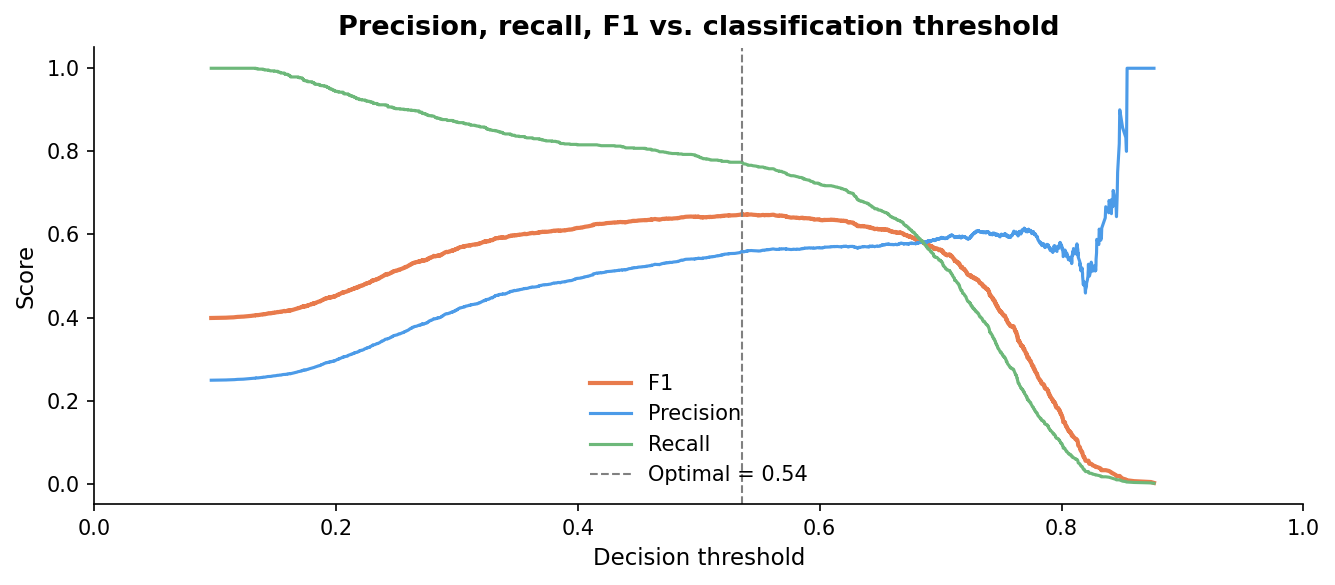

In [10]:
prec_arr, rec_arr, thresholds = precision_recall_curve(y_val, best_proba)
f1_arr = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-8)

best_thresh_idx = np.argmax(f1_arr)
best_thresh     = thresholds[best_thresh_idx]
print(f'Optimal threshold (max F1): {best_thresh:.3f}')
print(f'Precision at threshold:     {prec_arr[best_thresh_idx]:.3f}')
print(f'Recall at threshold:        {rec_arr[best_thresh_idx]:.3f}')
print(f'F1 at threshold:            {f1_arr[best_thresh_idx]:.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_arr[:-1],    label='F1',        color='#E87B4C', linewidth=2)
ax.plot(thresholds, prec_arr[:-1],  label='Precision', color='#4C9BE8', linewidth=1.5)
ax.plot(thresholds, rec_arr[:-1],   label='Recall',    color='#6DB87A', linewidth=1.5)
ax.axvline(best_thresh, color='gray', linestyle='--', linewidth=1,
           label=f'Optimal = {best_thresh:.2f}')
ax.set_title('Precision, recall, F1 vs. classification threshold')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('../outputs/figures/16_threshold_tuning.png', bbox_inches='tight', dpi=150)
plt.show()

At the default threshold of 0.50: precision = 0.54, recall = 0.79, F1 = 0.64.
The F1-optimal threshold is 0.536 - a small upward shift that trades
12 fewer true positives for slightly higher precision, raising F1 marginally
to 0.649.

For an HR retention context, the default 0.50 is actually preferable: it
catches more at-risk employees (recall 0.79 vs 0.77), and the cost of a
missed job-seeker (false negative) outweighs the cost of an unnecessary
check-in (false positive). Threshold tuning here confirms the default is
already near-optimal - no adjustment is needed.

## 8. SHAP Explainability
SHAP values translate model internals into feature-level contributions with direction - critical for communicating results to HR stakeholders.

In [11]:
explainer = shap.TreeExplainer(best_rf)

X_sample    = X_val.sample(n=min(1000, len(X_val)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# shap_values[1] = class 1 (job-seeker) SHAP values
shap_class1 = shap_values[1]
print('SHAP values shape:', shap_class1.shape)

SHAP values shape: (1000, 35)


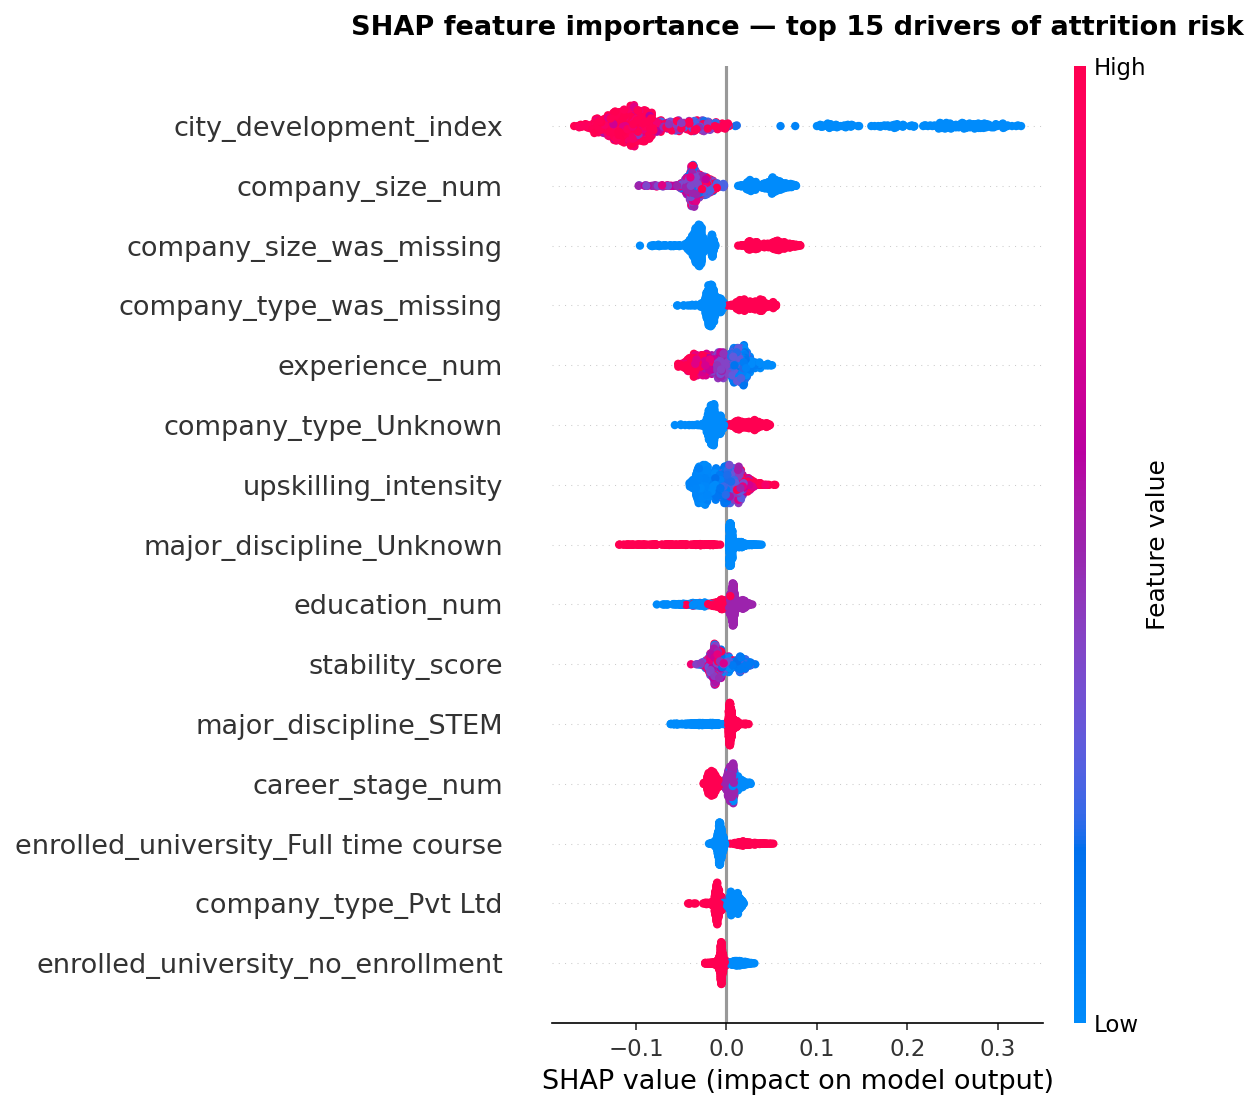

In [ ]:
# Beeswarm plot - shows distribution AND direction of each feature's impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_class1, X_sample, plot_type='dot',
                  max_display=15, show=False)
plt.title('SHAP feature importance - top 15 drivers of attrition risk',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/17_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

**How to read this chart:**  
- Each row = one feature. Each dot = one validation employee.  
- X-axis = SHAP value: positive pushes toward predicting job-seeking (class 1), negative toward staying  
- Color: red = high feature value, blue = low feature value  
- Example: if `city_development_index` shows blue dots on the RIGHT side → low CDI values push the model strongly toward predicting job-seeking → confirms EDA finding

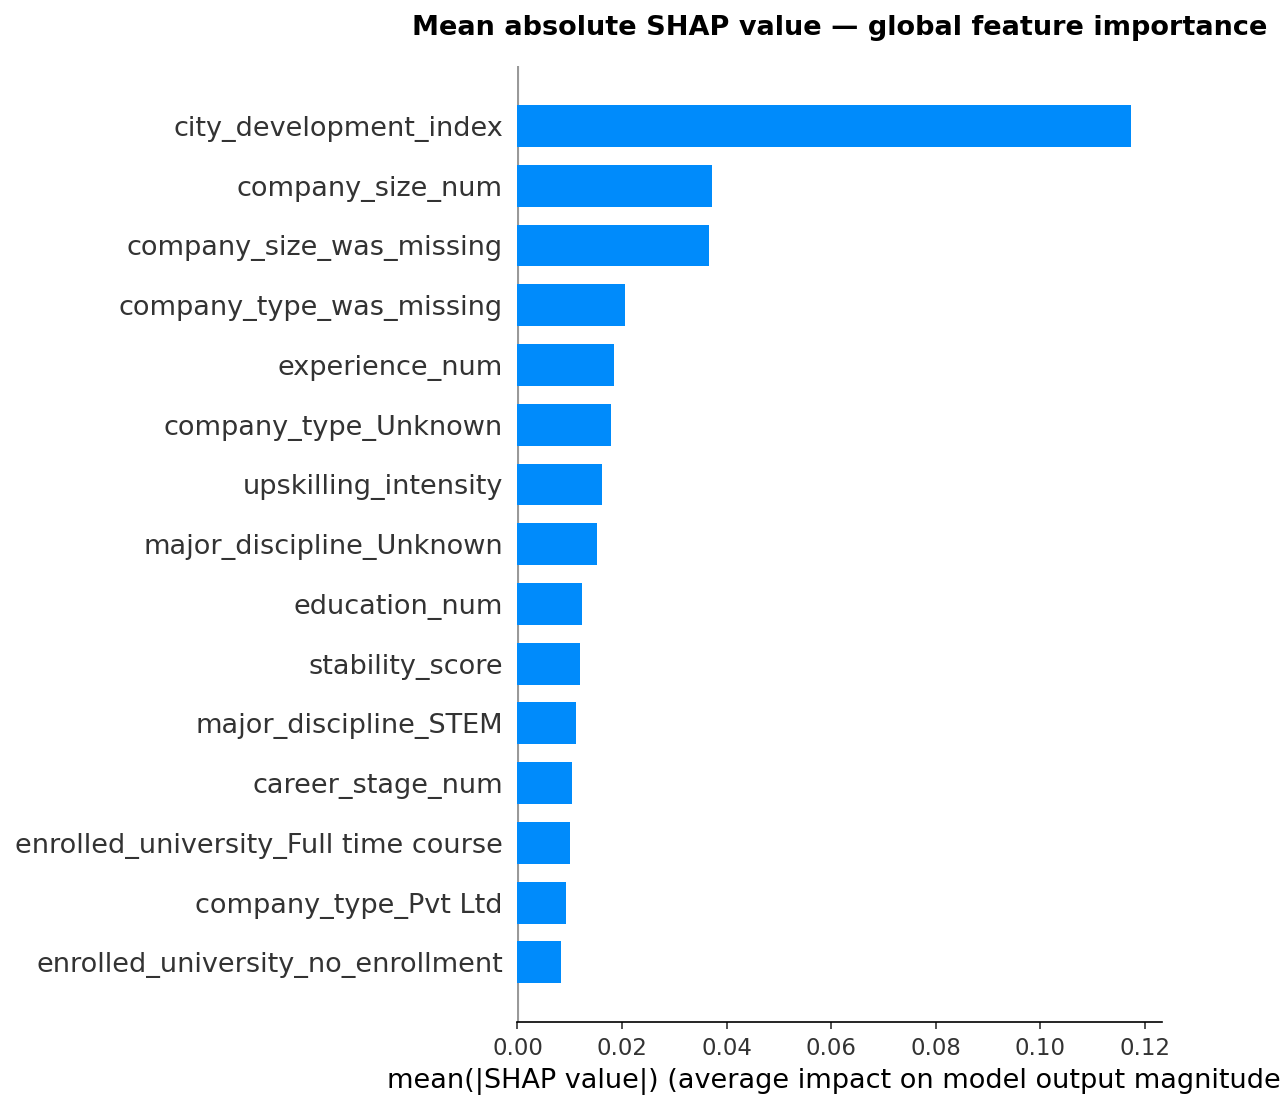

In [ ]:
# Bar plot - global mean absolute importance
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_class1, X_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('Mean absolute SHAP value - global feature importance',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/18_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

Top SHAP feature: city_development_index


<Figure size 1200x750 with 0 Axes>

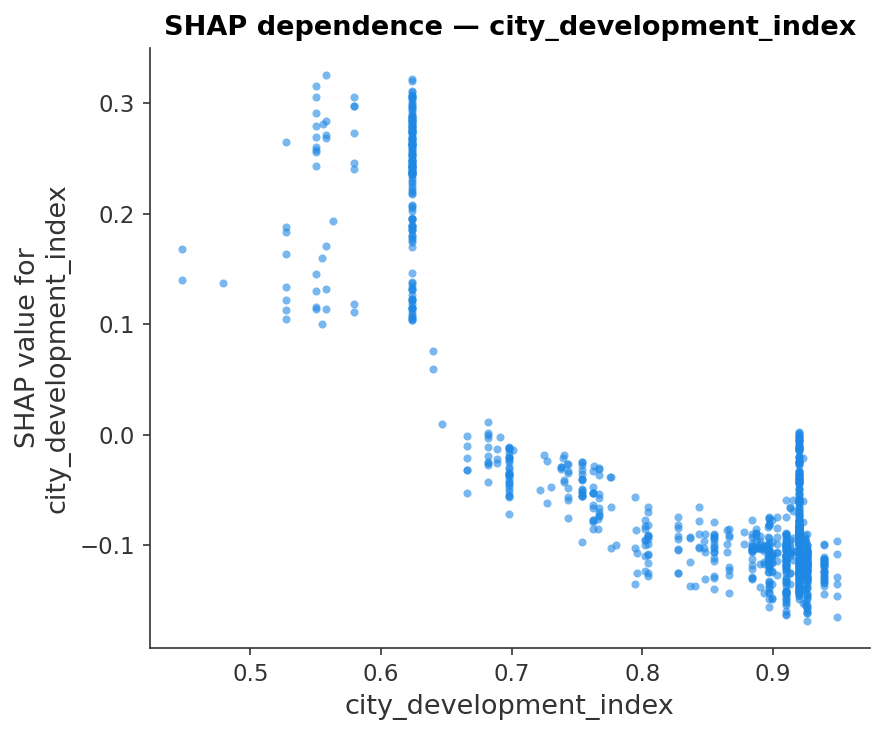

In [ ]:
# Dependence plot for top feature
top_feat_idx = np.abs(shap_class1).mean(axis=0).argmax()
top_feat     = X_sample.columns[top_feat_idx]
print(f'Top SHAP feature: {top_feat}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feat, shap_class1, X_sample,
                     interaction_index=None, show=False,
                     dot_size=15, alpha=0.6)
plt.title(f'SHAP dependence - {top_feat}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'../outputs/figures/19_shap_dependence_{top_feat}.png',
            bbox_inches='tight', dpi=150)
plt.show()

`city_development_index` and `experience_num` are the two dominant drivers - consistent with the EDA finding that CDI and career stage predict attrition more than any other structural factor. `stability_score`, `upskilling_intensity`, and `career_stage_num` (all engineered features) appear in the top 10, confirming the feature engineering added signal.

## 9. Risk Tier Segmentation

In [15]:
results_val = X_val.copy()
results_val['actual_target']  = y_val.values
results_val['attrition_prob'] = best_proba

def risk_tier(prob):
    if prob >= 0.60:   return 'High Risk'
    elif prob >= 0.35: return 'Medium Risk'
    else:              return 'Low Risk'

results_val['risk_tier'] = results_val['attrition_prob'].apply(risk_tier)

tier_summary = (results_val
                .groupby('risk_tier')
                .agg(employees=('actual_target','count'),
                     actual_seekers=('actual_target','sum'),
                     avg_prob=('attrition_prob','mean'))
                .round(3))
tier_summary['true_positive_rate'] = (
    tier_summary['actual_seekers'] / tier_summary['employees']).round(3)

print('Risk tier summary:')
display(tier_summary.sort_values('avg_prob', ascending=False))

Risk tier summary:


,employees,actual_seekers,avg_prob,true_positive_rate
risk_tier,,,,
High Risk,1213,689.0,0.733,0.568
Medium Risk,500,110.0,0.463,0.220
Low Risk,2119,156.0,0.225,0.074


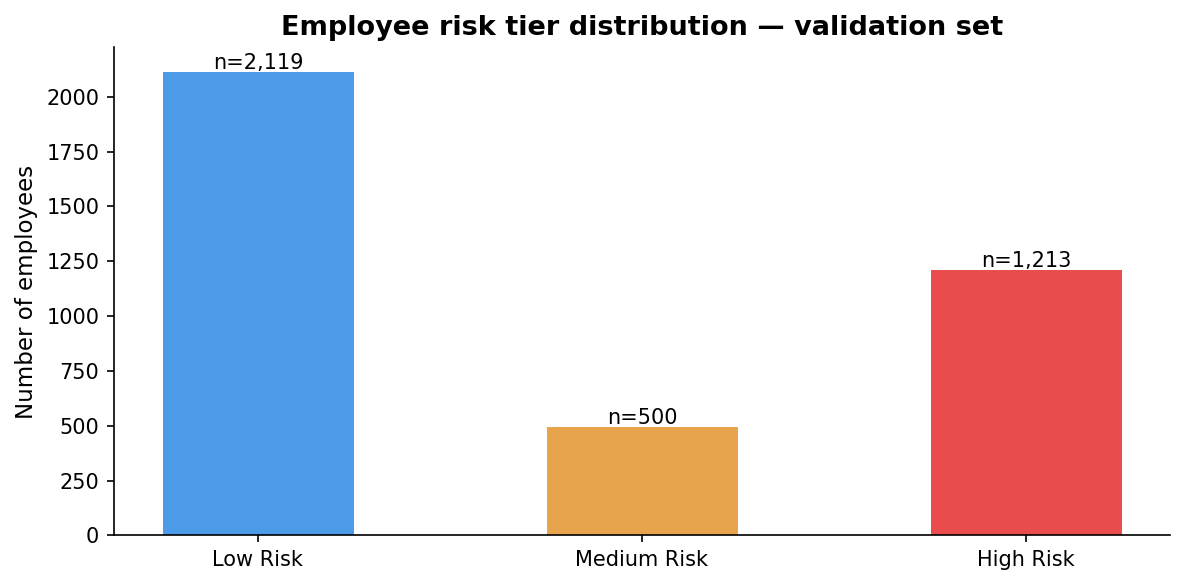

In [ ]:
tier_order  = ['Low Risk', 'Medium Risk', 'High Risk']
tier_counts = results_val['risk_tier'].value_counts().reindex(tier_order)
tier_colors = {'High Risk':'#E84C4C','Medium Risk':'#E8A44C','Low Risk':'#4C9BE8'}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=[tier_colors.get(t,'#888') for t in tier_counts.index],
              edgecolor='white', linewidth=0.5, width=0.5)

for bar, count in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'n={count:,}', ha='center', fontsize=10)

ax.set_title('Employee risk tier distribution - validation set')
ax.set_ylabel('Number of employees')
plt.tight_layout()
plt.savefig('../outputs/figures/20_risk_tier_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Save Model

In [17]:
joblib.dump(best_rf, '../outputs/hr_attrition_rf_model.pkl')
joblib.dump(X_train.columns.tolist(), '../outputs/feature_columns.pkl')

# Reload verification
loaded_model    = joblib.load('../outputs/hr_attrition_rf_model.pkl')
loaded_features = joblib.load('../outputs/feature_columns.pkl')

check_proba = loaded_model.predict_proba(X_val[loaded_features])[:, 1]
check_auc   = roc_auc_score(y_val, check_proba)
assert abs(check_auc - roc_auc_score(y_val, best_proba)) < 1e-6, 'FAIL: AUC mismatch after reload'

print(f'Model saved and verified.')
print(f'Reload AUC-ROC: {check_auc:.4f}  ✓')

Model saved and verified.
Reload AUC-ROC: 0.8123  ✓


---
## Business Summary

### Model Performance

| Model | AUC-ROC | F1 (seekers) |
|---|---|---|
| Dummy baseline | 0.50 | 0.00 |
| Logistic Regression | 0.79 | 0.59 |
| Random Forest | 0.81 | 0.63 |
| **RF Tuned (final)** | **0.81** | **0.64** |

### Top Attrition Drivers (SHAP)

1. **`city_development_index`** - dominant by a wide margin (SHAP ~0.12 vs. ~0.04 for #2). Low CDI strongly pushes toward job-seeking, confirming the EDA finding.

2. **`company_size_num`** - raw company size ordinal. Smaller company = higher risk.

3. **`company_size_was_missing`** - the indicator flag for missing company size. Directly validates the preprocessing decision to capture missingness as a feature. Candidates without company size data are structurally higher risk.

4. **`company_type_was_missing`** Missing company type is itself a strong attrition signal, likely identifying freelancers and contractors.

5. **`experience_num`** - early career stage increases risk and senior reduces it.


All four engineered features (`upskilling_intensity` #7, `stability_score` #10,
`career_stage_num` #12) appear in the top 15, confirming they added genuine
predictive signal beyond the raw inputs.


### Risk Tier Recommendations

| Tier | Action |
|---|---|
| High Risk (prob ≥ 0.60) | Manager check-in within 30 days, salary review, growth roadmap |
| Medium Risk (0.35–0.60) | Quarterly development conversations, learning budget offer |
| Low Risk (< 0.35) | Standard engagement, periodic pulse surveys |